In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from datetime import date

**API call to get all Published Datasets**

In [2]:
api_url_base = 'https://api.cellxgene.cziscience.com'
path_segment = '/datasets'
url = f'{api_url_base}/curation/v1{path_segment}'
r = requests.get(url)
datasets = r.json()

**Extract necessary information, assign publication based on the earliest published date for each Collection**

In [3]:
df = pd.DataFrame(datasets)[['collection_id','primary_cell_count','published_at']]
df['published_at'] = pd.to_datetime(df['published_at']).dt.date

collection_earliest = df.groupby('collection_id')['published_at'].min().reset_index()
collection_earliest.columns = ['collection_id', 'earliest_date']

df = df.merge(collection_earliest, on='collection_id')
df

,collection_id,primary_cell_count,published_at,earliest_date
0,79403b27-5330-43d6-b136-bf3976dd94b8,33932,2026-03-12,2026-03-12
1,9ceda3d2-a55e-4b82-a91a-0190d947459a,0,2026-03-11,2026-03-11
2,9ceda3d2-a55e-4b82-a91a-0190d947459a,401253,2026-03-11,2026-03-11
3,9ceda3d2-a55e-4b82-a91a-0190d947459a,0,2026-03-11,2026-03-11
4,ceef2841-5333-46ac-92ef-ccbe0c20fe55,427823,2026-03-10,2026-03-10
...,...,...,...,...
2075,5d445965-6f1a-4b68-ba3a-b8f765155d3a,65662,2020-08-26,2020-08-26
2076,d0e9c47b-4ce7-4f84-b182-eddcfa0b2658,81736,2020-08-26,2020-08-26
2077,2a79d190-a41e-4408-88c8-ac5c4d03c0fc,77650,2020-08-26,2020-08-26
2078,d0e9c47b-4ce7-4f84-b182-eddcfa0b2658,48890,2020-08-26,2020-08-26


**Extract citation stats for the CELLxGENE Discover publication**

In [4]:
eutils_base = 'https://eutils.ncbi.nlm.nih.gov/entrez/eutils/'
eurpmc_base = 'https://www.ebi.ac.uk/europepmc/webservices/rest/'

cxg_doi = '10.1093/nar/gkae1142'
q = f'{eutils_base}esearch.fcgi?db=pubmed&term={cxg_doi}[DOI]&retmode=json'
cxg_pmid = requests.get(q).json()['esearchresult']['idlist'][0]

u = f'{eurpmc_base}search?query=CITES%3A{cxg_pmid}_MED&pageSize=500&format=json'
r = requests.get(u).json()

cited_by = pd.DataFrame(r['resultList']['result'])[['firstPublicationDate']]
cited_by = cited_by['firstPublicationDate'].value_counts().to_frame().reset_index()
cited_by['firstPublicationDate'] = cited_by['firstPublicationDate'].apply(
    lambda x: x + '-01' if isinstance(x, str) and len(x) == 7 else x
)
cited_by['firstPublicationDate'] = pd.to_datetime(cited_by['firstPublicationDate']).dt.date
cited_by.rename(columns={'firstPublicationDate': 'earliest_date', 'count': 'cited_by'}, inplace=True)
cited_by.sort_values('earliest_date')

,earliest_date,cited_by
142,2023-11-05,1
53,2024-01-01,1
54,2024-03-23,1
55,2024-05-01,1
56,2024-05-02,1
...,...,...
110,2026-01-30,1
109,2026-02-01,1
24,2026-02-03,2
120,2026-02-24,1


**Calculate the relative date and running totals**

In [5]:
result = df.groupby('earliest_date').agg(
    collections=('collection_id', 'nunique'),
    primary_cells=('primary_cell_count', 'sum')
).reset_index()

result = result.merge(cited_by, on='earliest_date', how='outer')
result.fillna(0, inplace=True)

min_date = result['earliest_date'].min()
result['yr_published'] = result['earliest_date'].apply(lambda x: (x - min_date).days / 365.25)

result = result.sort_values('yr_published').reset_index(drop=True)

result['cumsum_collections'] = result['collections'].cumsum()
result['cumsum_primary_cells'] = result['primary_cells'].cumsum().apply(lambda x: x/1000000)

result['cumsum_cited_by'] = result['cited_by'].cumsum()
result

,earliest_date,collections,primary_cells,cited_by,yr_published,cumsum_collections,cumsum_primary_cells,cumsum_cited_by
0,2020-08-26,4.0,865124.0,0.0,0.000000,4.0,0.865124,0.0
1,2020-09-28,2.0,644647.0,0.0,0.090349,6.0,1.509771,0.0
2,2020-11-20,1.0,106136.0,0.0,0.235455,7.0,1.615907,0.0
3,2021-02-17,1.0,4837.0,0.0,0.479124,8.0,1.620744,0.0
4,2021-02-27,1.0,47019.0,0.0,0.506502,9.0,1.667763,0.0
...,...,...,...,...,...,...,...,...
398,2026-02-27,1.0,56676.0,1.0,5.505818,354.0,148.233451,189.0
399,2026-03-03,1.0,50093.0,0.0,5.516769,355.0,148.283544,189.0
400,2026-03-10,1.0,427823.0,0.0,5.535934,356.0,148.711367,189.0
401,2026-03-11,1.0,401253.0,0.0,5.538672,357.0,149.112620,189.0


**View the current counts**

In [6]:
print(result['cumsum_collections'].max(), 'Collections')
print(round(result['cumsum_primary_cells'].max(),2), 'M cells')
print(result['cumsum_cited_by'].max(), 'Cited Bys')

358.0 Collections
149.15 M cells
189.0 Cited Bys


**Set the y-axis parameters based on current counts**

In [7]:
coll_max, coll_del_mj, coll_del_mi = 400, 100, 50
cell_max, cell_del_mj, cell_del_mi = 150, 50, 25
cite_max, cite_del_mj, cite_del_mi = 200, 100, 25

**Plot the Collection & Primary Cell Count growth**

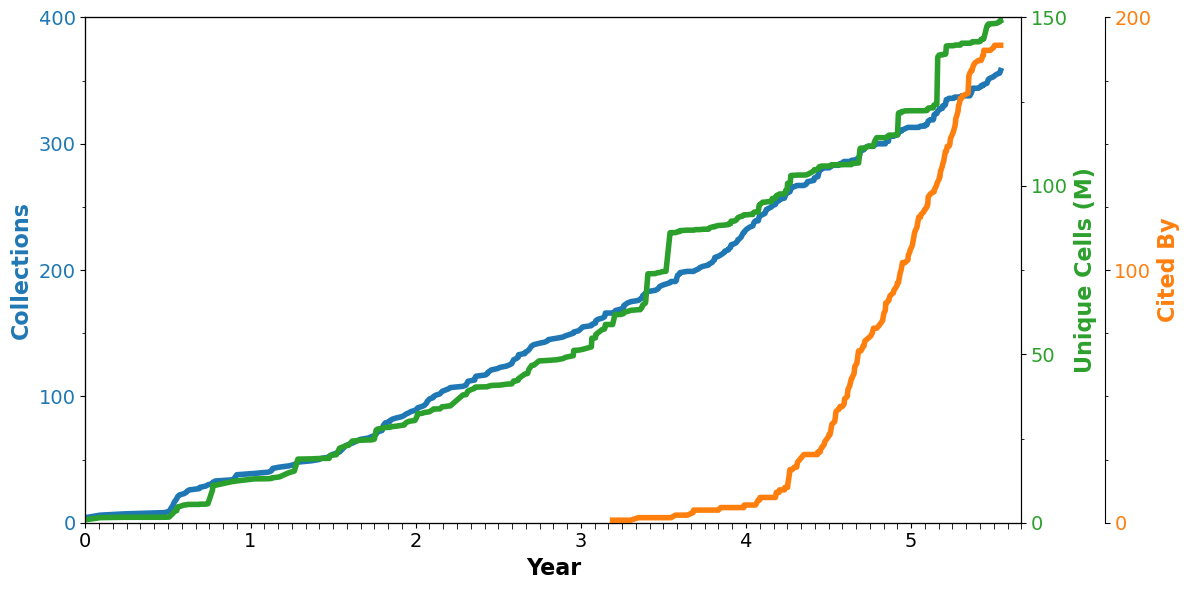

In [8]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# x-axis
yr_max = np.ceil(result['yr_published'].max() * 12) / 12
yr_del_mj, yr_del_mi = 1, 1/12
ax1.set_xlabel('Year', fontsize=16, fontweight='bold')
ax1.set_xlim(0, yr_max)
ax1.set_xticks(np.arange(0, yr_max + 0.1, yr_del_mj), minor=False)
ax1.set_xticks(np.arange(0, yr_max + 0.1, yr_del_mi), minor=True)
ax1.tick_params(axis='x', which='major', labelsize=14)
ax1.tick_params(axis='x', which='minor', length=4)

# left y-axis (collections)
color1 = 'tab:blue'
ax1.set_ylabel('Collections', color=color1, fontsize=16, fontweight='bold')
ax1.set_ylim(0, coll_max)
ax1.set_yticks(np.arange(0, coll_max + 0.1, coll_del_mj), minor=False)
ax1.set_yticks(np.arange(0, coll_max + 0.1, coll_del_mi), minor=True)
ax1.plot(result['yr_published'], result['cumsum_collections'], 
         color=color1, linewidth=4)
ax1.tick_params(axis='y', labelcolor=color1, labelsize=14)

# right y-axis (cells)
ax2 = ax1.twinx()
color2 = 'tab:green'
ax2.set_ylabel('Unique Cells (M)', color=color2, fontsize=16, fontweight='bold')
ax2.set_ylim(0, cell_max)
ax2.set_yticks(np.arange(0, cell_max + 0.1, cell_del_mj), minor=False)
ax2.set_yticks(np.arange(0, cell_max + 0.1, cell_del_mi), minor=True)
ax2.plot(result['yr_published'], result['cumsum_primary_cells'], 
         color=color2, linewidth=4)
ax2.tick_params(axis='y', labelcolor=color2, labelsize=14)

preprint_pub = date(2023, 11, 2)
cited_by_filtered = result[result['earliest_date'] >= preprint_pub]
# 2nd right y-axis (cited by)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color3 = 'tab:orange'
ax3.set_ylabel('Cited By', color=color3, fontsize=16, fontweight='bold')
ax3.set_ylim(0, cite_max)
ax3.set_yticks(np.arange(0, cite_max + 0.1, cite_del_mj), minor=False)
ax3.set_yticks(np.arange(0, cite_max + 0.1, cite_del_mi), minor=True)
ax3.plot(cited_by_filtered['yr_published'], cited_by_filtered['cumsum_cited_by'], 
         color=color3, linewidth=4)
ax3.tick_params(axis='y', labelcolor=color3, labelsize=14)

fig.tight_layout()
plt.savefig('cxg_growth.png', dpi=300, bbox_inches='tight')
plt.show()